In [10]:
import os
import torch
import torchvision
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger
from torchmetrics import Accuracy, Recall

# torch.set_float32_matmul_precision('medium') # if you can, disable if fails
print('PyTorch version:', torch.__version__)
print('Lightning version:', L.__version__)
print('CUDA available:', torch.cuda.is_available())
L.seed_everything(42)

Seed set to 42


PyTorch version: 2.9.0+cu128
Lightning version: 2.6.1
CUDA available: True


42

In [11]:
# Config variables
if os.path.isdir('data'):
    BASE_DIR = '.'
elif os.path.isdir('src/efficientnetv2/data'):
    BASE_DIR = 'src/efficientnetv2'
else:
    raise FileNotFoundError("Could not find 'data' folder. Run this notebook from repo root or src/efficientnetv2.")

DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR    = os.path.join(BASE_DIR, 'logs')

IMG_SIZE    = (216, 384)  # (height, width) keeps 16:9
BATCH_SIZE  = 16
NUM_CLASSES = 13
EPOCHS      = 50
LR          = 3e-4
WEIGHT_DECAY = 1e-4
WORKERS     = 2

VAL_FRACTION = 0.2
SPLIT_SEED   = 42

USE_SUBSET      = False
SUBSET_FRACTION = 0.2 if USE_SUBSET else 1.0
SUBSET_SEED     = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)


In [12]:
import sys

if os.path.isdir('src/efficientnetv2') and 'src/efficientnetv2' not in sys.path:
    sys.path.append('src/efficientnetv2')

from terraria_data import compute_imagefolder_mean_std, get_terraria_loaders

dataset_mean, dataset_std = compute_imagefolder_mean_std(
    data_dir=DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=64,
    workers=WORKERS,
)
print('Dataset mean:', [round(v, 4) for v in dataset_mean])
print('Dataset std:', [round(v, 4) for v in dataset_std])


train_loader, val_loader, class_names = get_terraria_loaders(
    data_dir=DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    workers=WORKERS,
    val_fraction=VAL_FRACTION,
    split_seed=SPLIT_SEED,
    subset_fraction=SUBSET_FRACTION,
    subset_seed=SUBSET_SEED,
    mean=dataset_mean,
    std=dataset_std,
)

assert len(class_names) == NUM_CLASSES, f'Expected {NUM_CLASSES} classes, got {len(class_names)}'
print('Classes:', class_names)
print(f'Train samples: {len(train_loader.dataset)}')
print(f'Val samples:   {len(val_loader.dataset)}')

train_subset = train_loader.dataset
train_targets = torch.tensor([train_subset.dataset.targets[i] for i in train_subset.indices], dtype=torch.long)
class_counts = torch.bincount(train_targets, minlength=NUM_CLASSES).float()
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts.clamp_min(1.0))
print('Class weights:', [round(v, 3) for v in class_weights.tolist()])


Dataset mean: [0.1473, 0.1647, 0.2079]
Dataset std: [0.1967, 0.215, 0.2937]
Classes: ['Corruption', 'Crimson', 'Desert', 'Dungeon', 'Forest', 'Hallow', 'Hell', 'Jungle', 'Mushroom', 'Ocean', 'Snow', 'Space', 'Underground']
Train samples: 547
Val samples:   129
Class weights: [0.877, 0.809, 1.052, 1.002, 0.657, 1.079, 1.002, 0.69, 4.675, 1.137, 0.979, 1.403, 1.052]


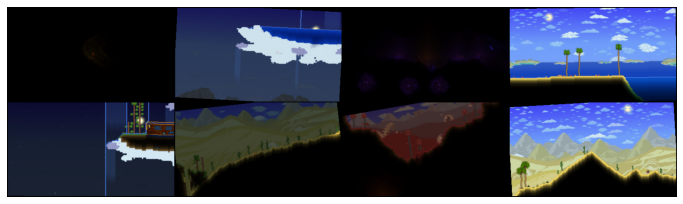

Preview labels: ['Dungeon', 'Space', 'Corruption', 'Ocean', 'Space', 'Desert', 'Crimson', 'Desert']


In [13]:
# quick sanity preview
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
num_show = min(8, images.size(0))

preview = images[:num_show].cpu()
mean = torch.tensor(dataset_mean).view(1, 3, 1, 1)
std = torch.tensor(dataset_std).view(1, 3, 1, 1)
preview = (preview * std + mean).clamp(0, 1)

grid = torchvision.utils.make_grid(preview, nrow=4)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

print('Preview labels:', [class_names[i] for i in labels[:num_show].tolist()])


In [14]:
#model definition (and funcs for logs and lr scheduler)
class BiomeClassifier(L.LightningModule):
    def __init__(self, num_classes, lr, weight_decay, max_epochs, class_weights=None):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.model = torchvision.models.efficientnet_v2_m(
            weights=torchvision.models.EfficientNet_V2_M_Weights.DEFAULT
        )
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = torch.nn.Linear(in_features, num_classes)
        self.criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.train_bal_acc = Recall(task='multiclass', num_classes=num_classes, average='macro')
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_bal_acc = Recall(task='multiclass', num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        images, labels = batch
        logits = self(images)
        loss = self.criterion(logits, labels)
        return loss, logits, labels

    def training_step(self, batch, batch_idx):
        loss, logits, labels = self._shared_step(batch)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_accuracy', self.train_acc(logits, labels), prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_balanced_accuracy', self.train_bal_acc(logits, labels), prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, labels = self._shared_step(batch)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_accuracy', self.val_acc(logits, labels), prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_balanced_accuracy', self.val_bal_acc(logits, labels), prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.hparams.max_epochs, eta_min=1e-6)
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}

In [ ]:
# training cell
# use tensorboard --logdir=logs during run to view training progress
class CleanTensorBoardLogger(TensorBoardLogger):
    def log_metrics(self, metrics, step):
        metrics = dict(metrics)
        metrics.pop('epoch', None)
        super().log_metrics(metrics, step)

class MetricsHistory(L.Callback):
    def __init__(self):
        self.train_accuracy = []
        self.val_accuracy   = []
        self.train_balanced_accuracy = []
        self.val_balanced_accuracy   = []

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        if trainer.state.fn != 'fit':
            return

        train_acc = trainer.callback_metrics.get('train_accuracy')
        val_acc = trainer.callback_metrics.get('val_accuracy')
        train_bal_acc = trainer.callback_metrics.get('train_balanced_accuracy')
        val_bal_acc = trainer.callback_metrics.get('val_balanced_accuracy')
        if train_acc is None or val_acc is None or train_bal_acc is None or val_bal_acc is None:
            return

        self.train_accuracy.append(float(train_acc.detach().cpu()))
        self.val_accuracy.append(float(val_acc.detach().cpu()))
        self.train_balanced_accuracy.append(float(train_bal_acc.detach().cpu()))
        self.val_balanced_accuracy.append(float(val_bal_acc.detach().cpu()))

logger = CleanTensorBoardLogger(
    save_dir=LOG_DIR,
    name='e-netv2-terraria',
    default_hp_metric=False,
)

logger.experiment.add_custom_scalars({
    'Loss': {'train_vs_val': ['Multiline', ['train_loss', 'val_loss']]},
    'Accuracy': {'train_vs_val': ['Multiline', ['train_accuracy', 'val_accuracy']]},
    'Balanced Accuracy': {'train_vs_val': ['Multiline', ['train_balanced_accuracy', 'val_balanced_accuracy']]},
})

metrics_history = MetricsHistory()

callbacks = [
    ModelCheckpoint(dirpath=OUTPUT_DIR, filename='best_efficientnet_v2_m_terraria',
                    monitor='val_accuracy', mode='max', save_top_k=1),
    EarlyStopping(monitor='val_accuracy', patience=5, mode='max'),
    TQDMProgressBar(refresh_rate=10),
    metrics_history,
]

model   = BiomeClassifier(num_classes=NUM_CLASSES, lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=EPOCHS, class_weights=class_weights)
log_every_n_steps = max(1, len(train_loader) // 5)
trainer = L.Trainer(max_epochs=EPOCHS, callbacks=callbacks, logger=logger, log_every_n_steps=log_every_n_steps, precision='16-mixed')
print(f'log_every_n_steps: {log_every_n_steps}')
trainer.fit(model, train_loader, val_loader)
print(f'TensorBoard logs: {logger.log_dir}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/davidkimgba/.local/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/davidkimgba/Terraria-Biome-Detection/src/efficientnetv2/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


log_every_n_steps: 7


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ EfficientNet       │ 20.2 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc     │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_bal_acc │ MulticlassRecall   │      0 │ train │     0 │
│ 4 │ val_acc       │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_bal_acc   │ MulticlassRecall   │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 20.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.2 M                                                                                               
Total estimated model params size (MB): 80                                                                         
Modules in train mode: 719                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

TensorBoard logs: ./logs/e-netv2-terraria/version_4


In [16]:
# display tensorboard logs
TB_LOG_DIR = logger.log_dir if 'logger' in globals() else LOG_DIR
%load_ext tensorboard
%tensorboard --logdir $TB_LOG_DIR


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [17]:
# eval and save
print('Training set metrics:')
trainer.validate(model, train_loader)
print('Validation set metrics:')
trainer.validate(model, val_loader)

final_path = os.path.join(OUTPUT_DIR, 'final_efficientnet_v2_m_terraria.pth')
torch.save(model.model.state_dict(), final_path)
print(f'Saved model to {final_path}')

best_ckpt_path = trainer.checkpoint_callback.best_model_path
if best_ckpt_path:
    best_model = BiomeClassifier.load_from_checkpoint(best_ckpt_path, map_location='cpu')
    best_path = os.path.join(OUTPUT_DIR, 'best_efficientnet_v2_m_terraria.pth')
    torch.save(best_model.model.state_dict(), best_path)
    print(f'Saved best model to {best_path} (from {best_ckpt_path})')
else:
    print('No best checkpoint was found to export.')


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9534883499145508     │
│   val_balanced_accuracy   │    0.9444366693496704     │
│         val_loss          │    0.14473532140254974    │
└───────────────────────────┴───────────────────────────┘

Saved model to ./checkpoints/final_efficientnet_v2_s_terraria.pth


In [ ]:
# # Optional: export final and best .pth weights to ONNX
# import copy
# import torch
# import onnx
#
# export_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device='cpu')
#
# final_export_model = copy.deepcopy(model.model).cpu().eval()
# final_export_model.load_state_dict(torch.load(final_path, map_location='cpu'))
# final_onnx_path = os.path.join(OUTPUT_DIR, 'final_efficientnet_v2_m_terraria.onnx')
# torch.onnx.export(
#     final_export_model,
#     export_input,
#     final_onnx_path,
#     input_names=['input'],
#     output_names=['logits'],
#     dynamic_axes={'input': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
#     opset_version=17,
# )
# print(f'Saved ONNX model to {final_onnx_path}')
# onnx.checker.check_model(onnx.load(final_onnx_path))
#
# if 'best_path' in locals():
#     best_export_model = copy.deepcopy(model.model).cpu().eval()
#     best_export_model.load_state_dict(torch.load(best_path, map_location='cpu'))
#     best_onnx_path = os.path.join(OUTPUT_DIR, 'best_efficientnet_v2_m_terraria.onnx')
#     torch.onnx.export(
#         best_export_model,
#         export_input,
#         best_onnx_path,
#         input_names=['input'],
#         output_names=['logits'],
#         dynamic_axes={'input': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
#         opset_version=17,
#     )
#     print(f'Saved ONNX model to {best_onnx_path}')
#     onnx.checker.check_model(onnx.load(best_onnx_path))
# else:
#     print('Run the best-checkpoint export block first to define best_path.')


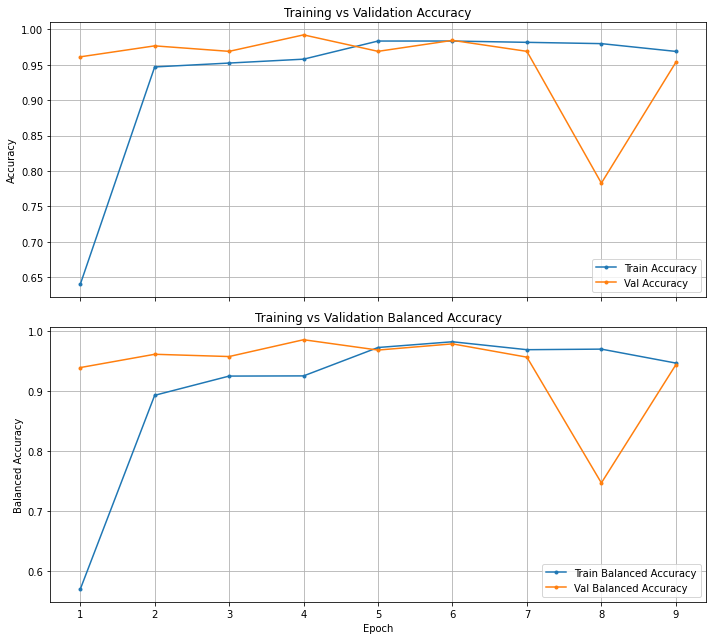

In [18]:
# Plot training vs validation accuracy and balanced accuracy
import matplotlib.pyplot as plt

train_values = metrics_history.train_accuracy
val_values = metrics_history.val_accuracy
train_bal_values = metrics_history.train_balanced_accuracy
val_bal_values = metrics_history.val_balanced_accuracy

if min(len(train_values), len(val_values), len(train_bal_values), len(val_bal_values)) == 0:
    raise ValueError('No accuracy history recorded. Run the training cell first.')

n = min(len(train_values), len(val_values), len(train_bal_values), len(val_bal_values))
if len(train_values) != n or len(val_values) != n or len(train_bal_values) != n or len(val_bal_values) != n:
    print(f'Warning: history length mismatch. Truncating to {n}.')
    train_values = train_values[:n]
    val_values = val_values[:n]
    train_bal_values = train_bal_values[:n]
    val_bal_values = val_bal_values[:n]

epochs = range(1, len(train_values) + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(epochs, train_values, label='Train Accuracy', marker='o', markersize=3)
axes[0].plot(epochs, val_values,   label='Val Accuracy',   marker='o', markersize=3)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_bal_values, label='Train Balanced Accuracy', marker='o', markersize=3)
axes[1].plot(epochs, val_bal_values,   label='Val Balanced Accuracy',   marker='o', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Training vs Validation Balanced Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()
